In [1]:
import pandas as pd 
import matplotlib.pyplot as plt
import seaborn as sns

In [2]:
df=pd.read_csv("smart_cart.csv")

In [6]:
df.isnull().sum()

ID                      0
Year_Birth              0
Education               0
Marital_Status          0
Income                 24
Kidhome                 0
Teenhome                0
Dt_Customer             0
Recency                 0
MntWines                0
MntFruits               0
MntMeatProducts         0
MntFishProducts         0
MntSweetProducts        0
MntGoldProds            0
NumDealsPurchases       0
NumWebPurchases         0
NumCatalogPurchases     0
NumStorePurchases       0
NumWebVisitsMonth       0
Complain                0
Response                0
dtype: int64

In [7]:
#handling missing values
df["Income"]=df["Income"].fillna(df["Income"].median())

In [8]:
df.isnull().sum()

ID                     0
Year_Birth             0
Education              0
Marital_Status         0
Income                 0
Kidhome                0
Teenhome               0
Dt_Customer            0
Recency                0
MntWines               0
MntFruits              0
MntMeatProducts        0
MntFishProducts        0
MntSweetProducts       0
MntGoldProds           0
NumDealsPurchases      0
NumWebPurchases        0
NumCatalogPurchases    0
NumStorePurchases      0
NumWebVisitsMonth      0
Complain               0
Response               0
dtype: int64

In [14]:
#age
df["Age"]=2026-df["Year_Birth"]

In [15]:
df.head()

,ID,Year_Birth,Education,Marital_Status,Income,Kidhome,Teenhome,Dt_Customer,Recency,MntWines,...,NumDealsPurchases,NumWebPurchases,NumCatalogPurchases,NumStorePurchases,NumWebVisitsMonth,Complain,Response,Age,customer_tenure_days,Customer_tenure_days
0,5524,1957,Graduation,Single,58138.0,0,0,2012-09-04,58,635,...,3,8,10,4,7,0,1,69,663,663
1,2174,1954,Graduation,Single,46344.0,1,1,2014-03-08,38,11,...,2,1,1,2,5,0,0,72,113,113
2,4141,1965,Graduation,Together,71613.0,0,0,2013-08-21,26,426,...,1,8,2,10,4,0,0,61,312,312
3,6182,1984,Graduation,Together,26646.0,1,0,2014-02-10,26,11,...,2,2,0,4,6,0,0,42,139,139
4,5324,1981,PhD,Married,58293.0,1,0,2014-01-19,94,173,...,5,5,3,6,5,0,0,45,161,161


In [16]:
# customer joining date
df["Dt_Customer"]=pd.to_datetime(df["Dt_Customer"],dayfirst="True")
reference_date=df["Dt_Customer"].max()
df["Customer_tenure_days"]=(reference_date-df["Dt_Customer"]).dt.days

In [21]:
#spending
df["Total_spending"]=df["MntWines"]+df["MntFruits"]+df["MntMeatProducts"]+df["MntFishProducts"]+df["MntSweetProducts"]+df["MntGoldProds"]

In [22]:
#kids
df["Children"]=df["Kidhome"]+df["Teenhome"]

In [23]:
df.head()

,ID,Year_Birth,Education,Marital_Status,Income,Kidhome,Teenhome,Dt_Customer,Recency,MntWines,...,NumCatalogPurchases,NumStorePurchases,NumWebVisitsMonth,Complain,Response,Age,customer_tenure_days,Customer_tenure_days,Total_spending,Children
0,5524,1957,Graduation,Single,58138.0,0,0,2012-09-04,58,635,...,10,4,7,0,1,69,663,663,1617,0
1,2174,1954,Graduation,Single,46344.0,1,1,2014-03-08,38,11,...,1,2,5,0,0,72,113,113,27,2
2,4141,1965,Graduation,Together,71613.0,0,0,2013-08-21,26,426,...,2,10,4,0,0,61,312,312,776,0
3,6182,1984,Graduation,Together,26646.0,1,0,2014-02-10,26,11,...,0,4,6,0,0,42,139,139,53,1
4,5324,1981,PhD,Married,58293.0,1,0,2014-01-19,94,173,...,3,6,5,0,0,45,161,161,422,1


In [32]:
df["Education"].value_counts()

Education
Graduate         1127
PostGraduate      856
UnderGraduate     257
Name: count, dtype: int64

In [33]:
# education
df["Education"]=df["Education"].replace({
    "2n Cycle":"UnderGraduate",
    "Basic":"UnderGraduate",
    "Graduation":"Graduate",
    "Master":"PostGraduate",
    "PhD":"PostGraduate"
})

In [34]:
df["Education"].value_counts()

Education
Graduate         1127
PostGraduate      856
UnderGraduate     257
Name: count, dtype: int64

In [36]:
df["Marital_Status"].value_counts()

Marital_Status
Married     864
Together    580
Single      480
Divorced    232
Widow        77
Alone         3
Absurd        2
YOLO          2
Name: count, dtype: int64

In [37]:
#marital status

df["Living_with"]=df["Marital_Status"].replace({
    "Married":"Partner",
    "Together":"Partner",
    "Single":"Alone",
    "Divorced":"Alone",
    "Widow":"Alone",
    "Absurd":"Alone",
    "YOLO":"Alone"
})

In [39]:
df.columns

Index(['ID', 'Year_Birth', 'Education', 'Marital_Status', 'Income', 'Kidhome',
       'Teenhome', 'Dt_Customer', 'Recency', 'MntWines', 'MntFruits',
       'MntMeatProducts', 'MntFishProducts', 'MntSweetProducts',
       'MntGoldProds', 'NumDealsPurchases', 'NumWebPurchases',
       'NumCatalogPurchases', 'NumStorePurchases', 'NumWebVisitsMonth',
       'Complain', 'Response', 'Age', 'customer_tenure_days',
       'Customer_tenure_days', 'Total_spending', 'Children', 'Living_with'],
      dtype='object')

# drop columns


In [43]:
cols=["ID","Year_Birth","Marital_Status","Kidhome","Teenhome","Dt_Customer","customer_tenure_days"]
spending_cols=["MntMeatProducts","MntFishProducts","MntWines","MntFruits","MntSweetProducts","MntGoldProds"]
total_cols=cols+spending_cols
df_cleaned=df.drop(columns=total_cols)

In [46]:
df_cleaned.columns

Index(['Education', 'Income', 'Recency', 'NumDealsPurchases',
       'NumWebPurchases', 'NumCatalogPurchases', 'NumStorePurchases',
       'NumWebVisitsMonth', 'Complain', 'Response', 'Age',
       'Customer_tenure_days', 'Total_spending', 'Children', 'Living_with'],
      dtype='object')

In [45]:
df.shape

(2240, 28)

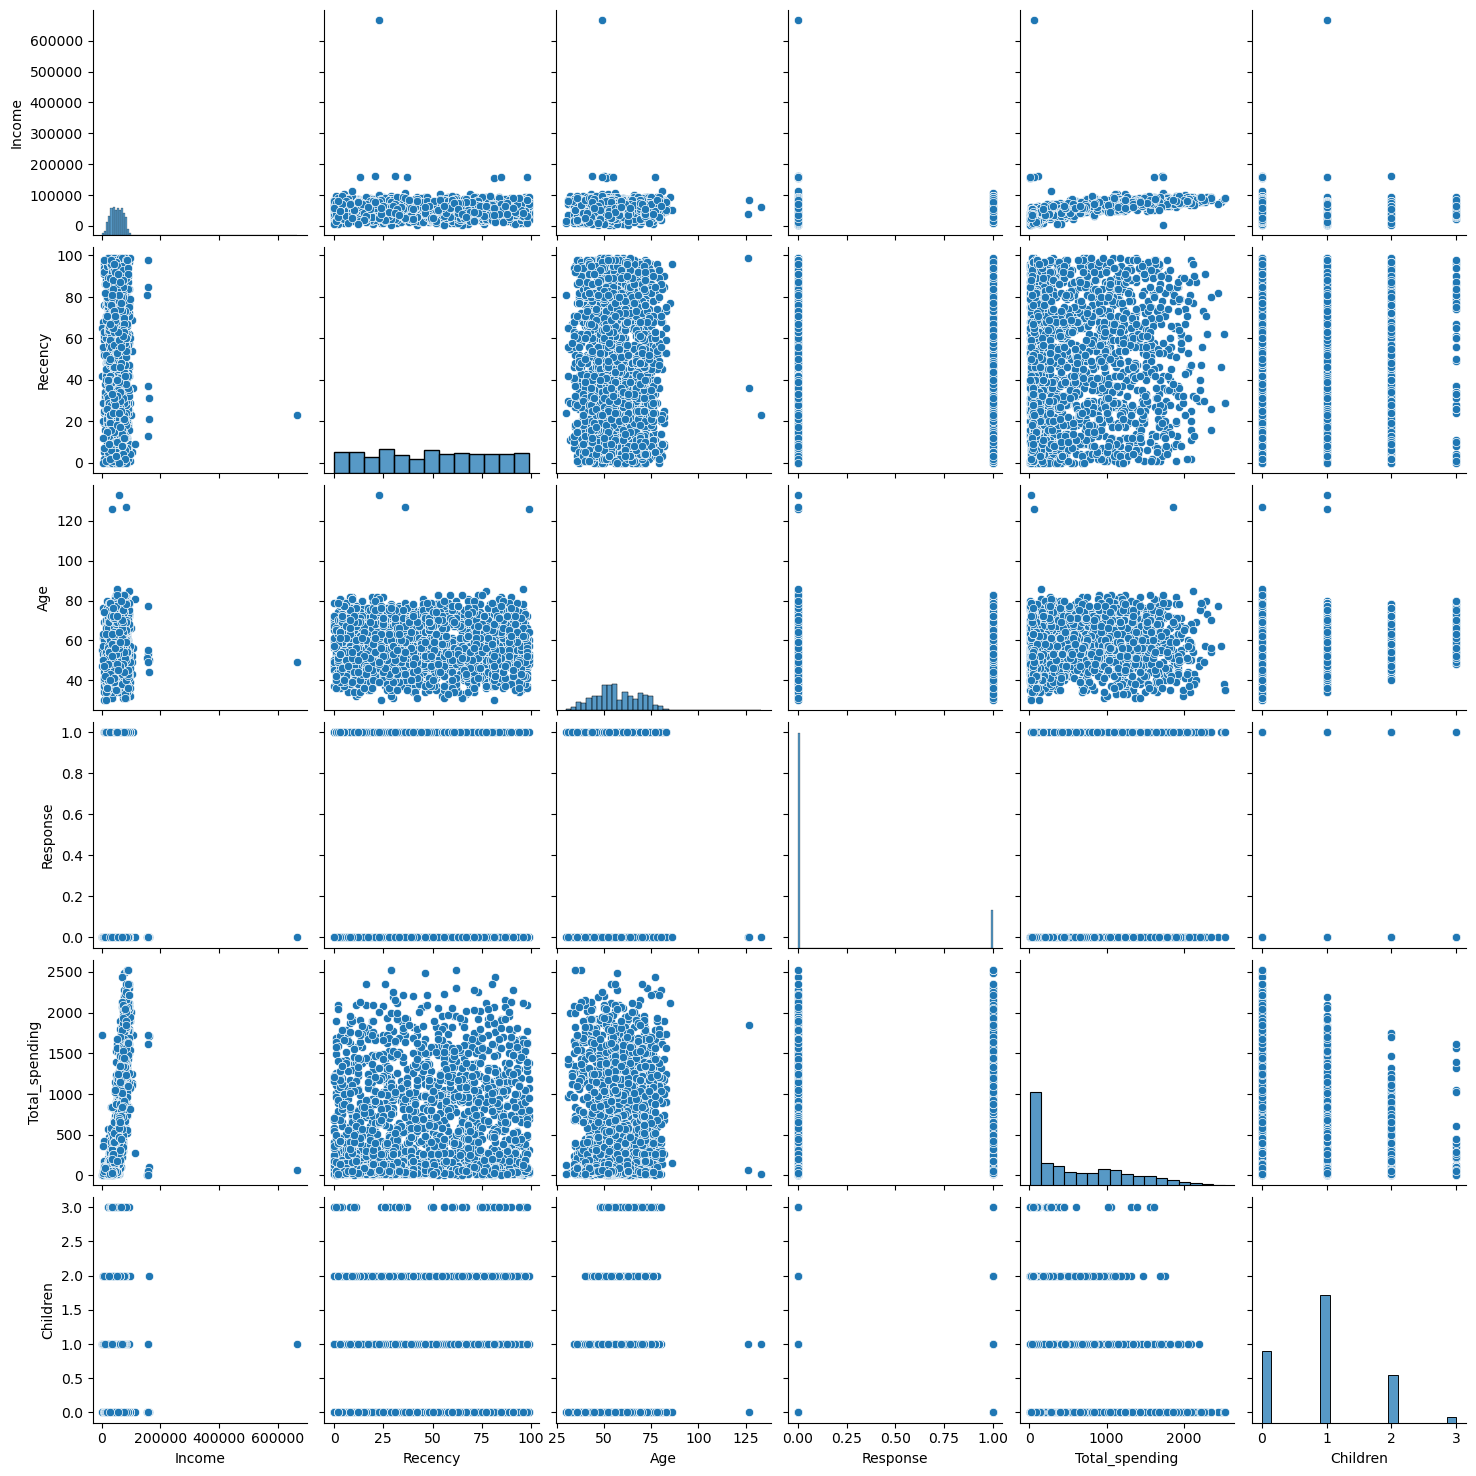

In [47]:
cols=["Income","Recency","Age","Response","Total_spending","Children"]
sns.pairplot(df[cols])

In [48]:
## outliers
print("data with outliers",len(df_cleaned))
df_cleaned=df_cleaned[(df_cleaned["Age"]<90)]
df_cleaned=df_cleaned[(df_cleaned["Income"]<600_000)]
print("data without outliers",len(df_cleaned))

data with outliers 2240
data without outliers 2236


In [49]:
corr=df_cleaned.corr(numeric_only=True)


<Axes: >

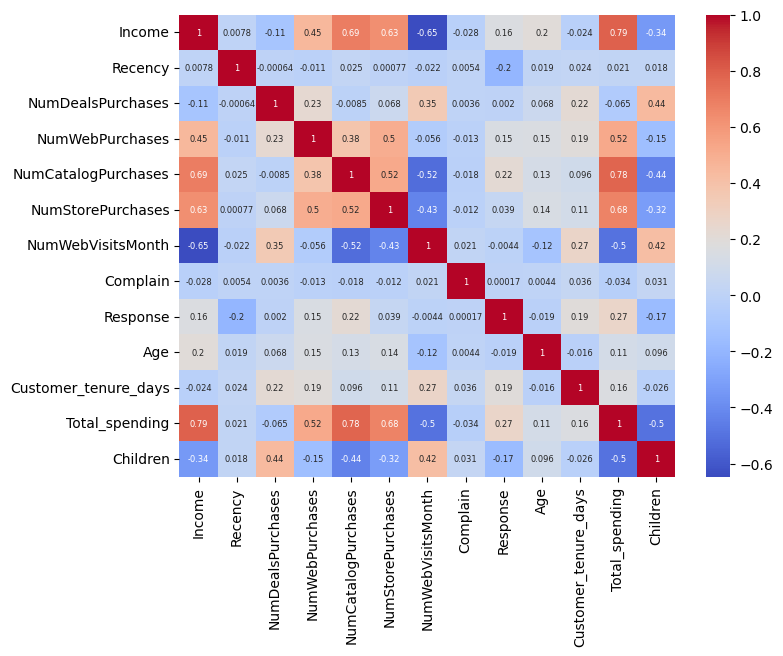

In [52]:
plt.figure(figsize=(8,6))
sns.heatmap(
    corr,
    annot=True,
    annot_kws={"size":6},
    cmap="coolwarm"
)

In [53]:
df_cleaned.head()

,Education,Income,Recency,NumDealsPurchases,NumWebPurchases,NumCatalogPurchases,NumStorePurchases,NumWebVisitsMonth,Complain,Response,Age,Customer_tenure_days,Total_spending,Children,Living_with
0,Graduate,58138.0,58,3,8,10,4,7,0,1,69,663,1617,0,Alone
1,Graduate,46344.0,38,2,1,1,2,5,0,0,72,113,27,2,Alone
2,Graduate,71613.0,26,1,8,2,10,4,0,0,61,312,776,0,Partner
3,Graduate,26646.0,26,2,2,0,4,6,0,0,42,139,53,1,Partner
4,PostGraduate,58293.0,94,5,5,3,6,5,0,0,45,161,422,1,Partner


# encoding



In [56]:
from sklearn.preprocessing import OneHotEncoder
ohe=OneHotEncoder()
cat_col=["Living_with","Education"]
en_col=ohe.fit_transform(df_cleaned[cat_col])
en_df=pd.DataFrame(en_col.toarray(),columns=ohe.get_feature_names_out(cat_col),index=df_cleaned.index)

In [57]:
en_df.head()

,Living_with_Alone,Living_with_Partner,Education_Graduate,Education_PostGraduate,Education_UnderGraduate
0,1.0,0.0,1.0,0.0,0.0
1,1.0,0.0,1.0,0.0,0.0
2,0.0,1.0,1.0,0.0,0.0
3,0.0,1.0,1.0,0.0,0.0
4,0.0,1.0,0.0,1.0,0.0


In [59]:
df_encoded=pd.concat([df_cleaned.drop(columns=cat_col),en_df],axis=1)

# scaling

In [61]:
df_encoded.head()

,Income,Recency,NumDealsPurchases,NumWebPurchases,NumCatalogPurchases,NumStorePurchases,NumWebVisitsMonth,Complain,Response,Age,Customer_tenure_days,Total_spending,Children,Living_with_Alone,Living_with_Partner,Education_Graduate,Education_PostGraduate,Education_UnderGraduate
0,58138.0,58,3,8,10,4,7,0,1,69,663,1617,0,1.0,0.0,1.0,0.0,0.0
1,46344.0,38,2,1,1,2,5,0,0,72,113,27,2,1.0,0.0,1.0,0.0,0.0
2,71613.0,26,1,8,2,10,4,0,0,61,312,776,0,0.0,1.0,1.0,0.0,0.0
3,26646.0,26,2,2,0,4,6,0,0,42,139,53,1,0.0,1.0,1.0,0.0,0.0
4,58293.0,94,5,5,3,6,5,0,0,45,161,422,1,0.0,1.0,0.0,1.0,0.0


In [62]:
from sklearn.preprocessing import StandardScaler

In [63]:
X=df_encoded

In [64]:
scaler=StandardScaler()
X_scaled=scaler.fit_transform(X)

# visualize

In [70]:
from sklearn.decomposition import PCA
pca=PCA(n_components=3)
X_pca=pca.fit_transform(X_scaled)

In [73]:
pca.explained_variance_ratio_

array([0.23163158, 0.11385454, 0.10405815])

Text(0.5, 0.92, '3d plot')

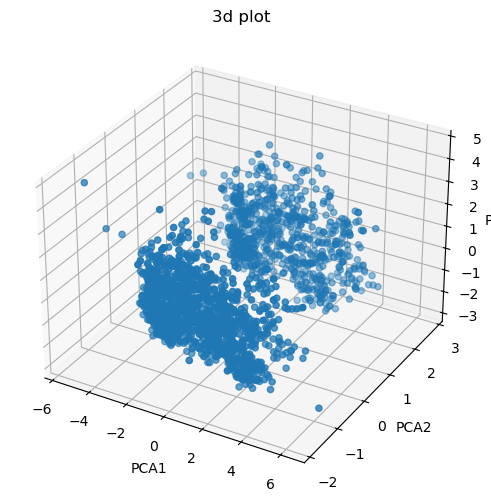

In [72]:
fig=plt.figure(figsize=(8,6))
ax=fig.add_subplot(111,projection="3d")
ax.scatter(X_pca[:,0],X_pca[:,1],X_pca[:,2])
ax.set_xlabel("PCA1")
ax.set_ylabel("PCA2")
ax.set_zlabel("PCA3")
ax.set_title("3d plot")

In [69]:
pca.explained_variance_ratio_

array([0.23163158, 0.11385454])

# choose k value


In [77]:
from sklearn.cluster import KMeans
from kneed import KneeLocator
wcss=[]
for k in range(1,11):
    kmeans=KMeans(n_clusters=k,random_state=42)
    kmeans.fit_predict(X_pca)
    wcss.append(kmeans.inertia_)


C:\Users\ranas\anaconda3\Lib\site-packages\sklearn\cluster\_kmeans.py:1419: UserWarning: KMeans is known to have a memory leak on Windows with MKL, when there are less chunks than available threads. You can avoid it by setting the environment variable OMP_NUM_THREADS=9.
  warnings.warn(
C:\Users\ranas\anaconda3\Lib\site-packages\sklearn\cluster\_kmeans.py:1419: UserWarning: KMeans is known to have a memory leak on Windows with MKL, when there are less chunks than available threads. You can avoid it by setting the environment variable OMP_NUM_THREADS=9.
  warnings.warn(
C:\Users\ranas\anaconda3\Lib\site-packages\sklearn\cluster\_kmeans.py:1419: UserWarning: KMeans is known to have a memory leak on Windows with MKL, when there are less chunks than available threads. You can avoid it by setting the environment variable OMP_NUM_THREADS=9.
  warnings.warn(
C:\Users\ranas\anaconda3\Lib\site-packages\sklearn\cluster\_kmeans.py:1419: UserWarning: KMeans is known to have a memory leak on Window

In [78]:
knee=KneeLocator(range(1,11),wcss,curve="convex",direction="decreasing")
optimal_k=knee.elbow

In [80]:
print("best k=",optimal_k)

best k= 4


Text(0, 0.5, 'wcss')

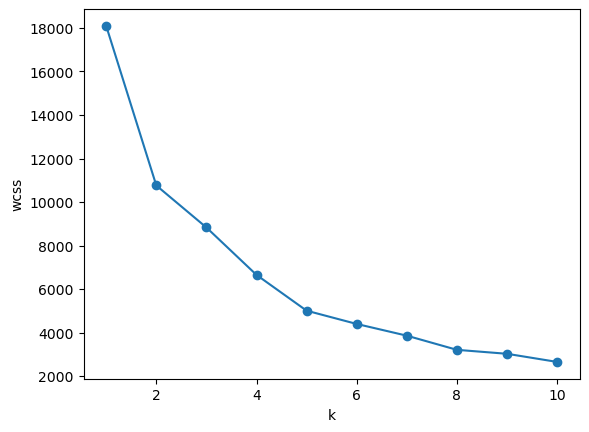

In [81]:
#plot
plt.plot(range(1,11),wcss,marker="o")
plt.xlabel("k")
plt.ylabel("wcss")

# silhoutte score

C:\Users\ranas\anaconda3\Lib\site-packages\sklearn\cluster\_kmeans.py:1419: UserWarning: KMeans is known to have a memory leak on Windows with MKL, when there are less chunks than available threads. You can avoid it by setting the environment variable OMP_NUM_THREADS=9.
  warnings.warn(
C:\Users\ranas\anaconda3\Lib\site-packages\sklearn\cluster\_kmeans.py:1419: UserWarning: KMeans is known to have a memory leak on Windows with MKL, when there are less chunks than available threads. You can avoid it by setting the environment variable OMP_NUM_THREADS=9.
  warnings.warn(
C:\Users\ranas\anaconda3\Lib\site-packages\sklearn\cluster\_kmeans.py:1419: UserWarning: KMeans is known to have a memory leak on Windows with MKL, when there are less chunks than available threads. You can avoid it by setting the environment variable OMP_NUM_THREADS=9.
  warnings.warn(
C:\Users\ranas\anaconda3\Lib\site-packages\sklearn\cluster\_kmeans.py:1419: UserWarning: KMeans is known to have a memory leak on Window

Text(0, 0.5, 'silhouette score')

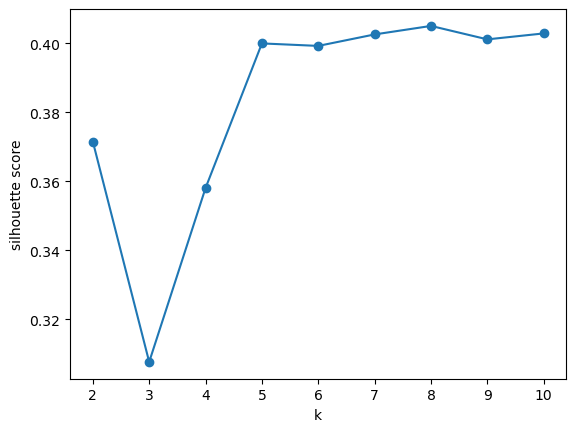

In [83]:
from sklearn.metrics import silhouette_score 
scores=[]
for k in range(2,11):
    kmeans=KMeans(n_clusters=k,random_state=42)
    labels=kmeans.fit_predict(X_pca)
    score=silhouette_score(X_pca,labels)
    scores.append(score)
#plot
plt.plot(range(2,11), scores ,marker="o")
plt.xlabel("k")
plt.ylabel("silhouette score")

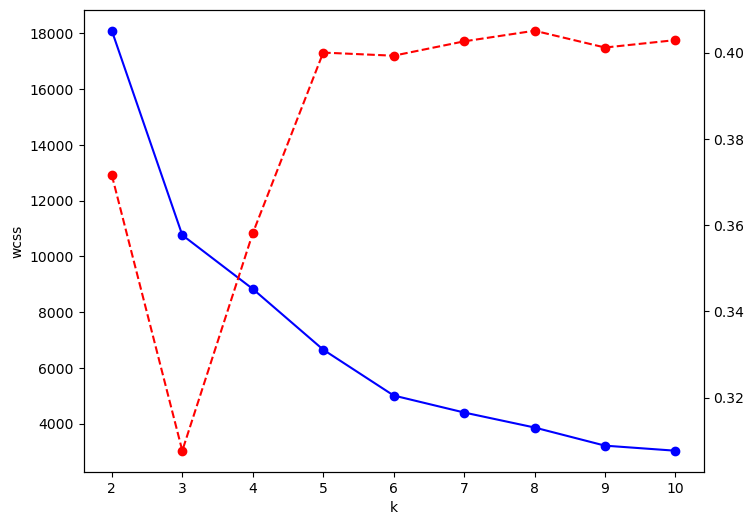

In [86]:
# combined plot
k_range=range(2,11)
fig,ax1=plt.subplots(figsize=(8,6))
ax1.plot(k_range,wcss[:len(k_range)],marker="o",color="blue")
ax1.set_xlabel("k")
ax1.set_ylabel("wcss")
ax2=ax1.twinx()
ax2.plot(k_range,scores[:len(k_range)],marker="o",color="red",linestyle="--")

In [88]:
kmeans=KMeans(n_clusters=4,random_state=42)
labels_kmeans=kmeans.fit_predict(X_pca)

C:\Users\ranas\anaconda3\Lib\site-packages\sklearn\cluster\_kmeans.py:1419: UserWarning: KMeans is known to have a memory leak on Windows with MKL, when there are less chunks than available threads. You can avoid it by setting the environment variable OMP_NUM_THREADS=9.
  warnings.warn(


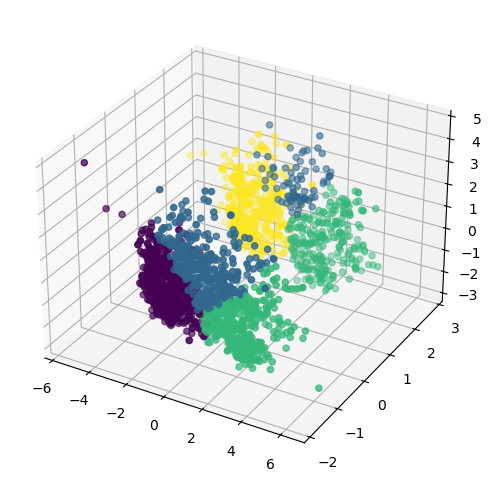

In [91]:
fig=plt.figure(figsize=(8,6))
ax=fig.add_subplot(111,projection="3d")
ax.scatter(X_pca[:,0],X_pca[:,1],X_pca[:,2],c=labels_kmeans)

In [92]:
from sklearn.cluster import AgglomerativeClustering

In [96]:
agg_clf=AgglomerativeClustering(n_clusters=4,linkage="ward")
labels_agg=agg_clf.fit_predict(X_pca)

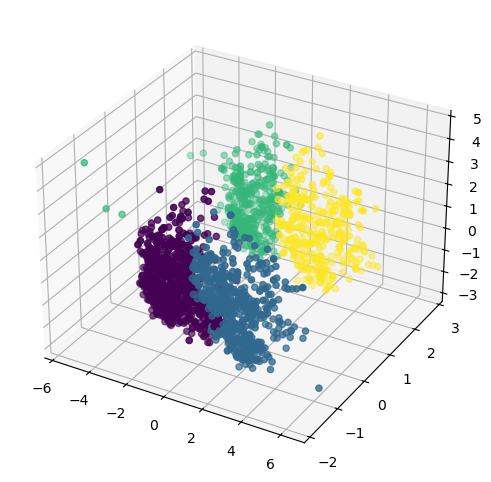

In [97]:
fig=plt.figure(figsize=(8,6))
ax=fig.add_subplot(111,projection="3d")
ax.scatter(X_pca[:,0],X_pca[:,1],X_pca[:,2],c=labels_agg)

In [106]:
#characterization
X["clusters"]=labels_agg

In [107]:
X.head()

,Income,Recency,NumDealsPurchases,NumWebPurchases,NumCatalogPurchases,NumStorePurchases,NumWebVisitsMonth,Complain,Response,Age,Customer_tenure_days,Total_spending,Children,Living_with_Alone,Living_with_Partner,Education_Graduate,Education_PostGraduate,Education_UnderGraduate,clusters
0,58138.0,58,3,8,10,4,7,0,1,69,663,1617,0,1.0,0.0,1.0,0.0,0.0,3
1,46344.0,38,2,1,1,2,5,0,0,72,113,27,2,1.0,0.0,1.0,0.0,0.0,2
2,71613.0,26,1,8,2,10,4,0,0,61,312,776,0,0.0,1.0,1.0,0.0,0.0,1
3,26646.0,26,2,2,0,4,6,0,0,42,139,53,1,0.0,1.0,1.0,0.0,0.0,0
4,58293.0,94,5,5,3,6,5,0,0,45,161,422,1,0.0,1.0,0.0,1.0,0.0,0


<Axes: xlabel='clusters', ylabel='count'>

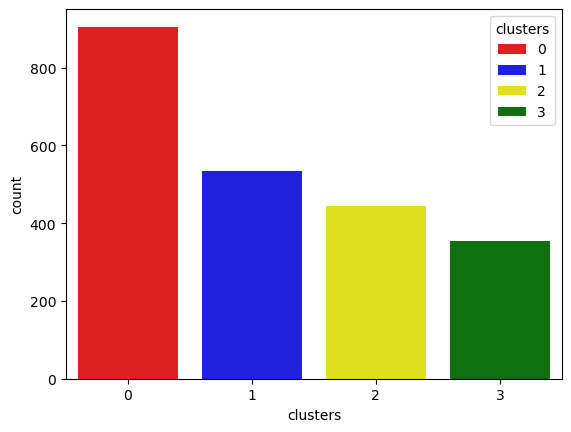

In [108]:
pal=["red","blue","yellow","green"]
sns.countplot(x=X["clusters"],palette=pal,hue=X["clusters"])

<Axes: xlabel='Total_spending', ylabel='Income'>

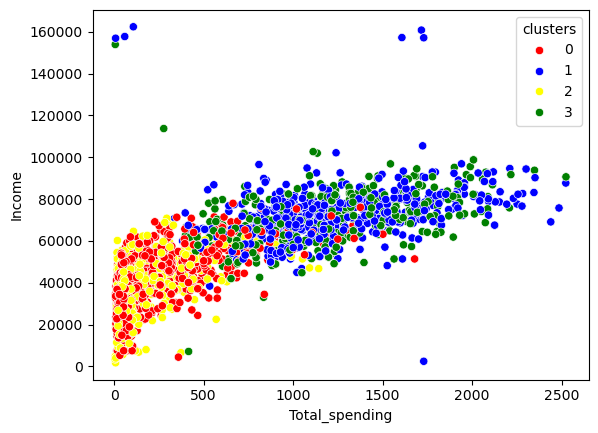

In [110]:
sns.scatterplot(x=X["Total_spending"],y=X["Income"],hue=X["clusters"],palette=pal)

In [112]:
cluster_summary=X.groupby("clusters").mean()
print(cluster_summary)

                Income    Recency  NumDealsPurchases  NumWebPurchases  \
clusters                                                                
0         39680.580110  48.914917           2.594475         3.153591   
1         72808.445693  49.202247           1.958801         5.687266   
2         36960.143018  48.319820           2.594595         2.713964   
3         70722.681303  50.504249           1.855524         5.790368   

          NumCatalogPurchases  NumStorePurchases  NumWebVisitsMonth  Complain  \
clusters                                                                        
0                    0.969061           4.143646           6.307182  0.011050   
1                    5.498127           8.659176           3.580524  0.005618   
2                    0.837838           3.623874           6.659910  0.011261   
3                    5.014164           8.430595           3.728045  0.005666   

          Response        Age  Customer_tenure_days  Total_spending  Child